# XGBoost Hotspot Prediction Model
Binary classification: predict whether a location is a crime hotspot.

**Pipeline:**
1. Load data from `feature_engineering/`
2. Baseline XGBoost with Stratified 5-Fold CV
3. Hyperparameter tuning with Optuna
4. Final evaluation on test set

In [1]:
# Install dependencies if needed
# !pip install xgboost optuna scikit-learn pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

RANDOM_STATE = 42
DATA_DIR = '../data/feature_engineering/'

## 1. Load Data

In [3]:
X_train = pd.read_csv(DATA_DIR + 'X_train.csv')
y_train = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
X_test  = pd.read_csv(DATA_DIR + 'X_test.csv')
y_test  = pd.read_csv(DATA_DIR + 'y_test.csv').squeeze()

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Class distribution (train):\n{y_train.value_counts()}')

# Class imbalance ratio for scale_pos_weight
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale_pos_weight = neg / pos
print(f'\nscale_pos_weight = {scale_pos_weight:.4f}')

X_train: (539, 35), X_test: (77, 35)
Class distribution (train):
hotspot
0    399
1    140
Name: count, dtype: int64

scale_pos_weight = 2.8500


## 2. Baseline Model — Stratified 5-Fold CV

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

scoring = ['precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(
    baseline, X_train, y_train,
    cv=cv, scoring=scoring,
    return_train_score=False
)

print('=== Baseline 5-Fold CV Results ===')
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f'{metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

=== Baseline 5-Fold CV Results ===
precision   : 0.8806 ± 0.0378
recall      : 0.8786 ± 0.0535
f1          : 0.8782 ± 0.0323
roc_auc     : 0.9718 ± 0.0135


## 3. Hyperparameter Tuning with Optuna

In [5]:
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
    }

    model = XGBClassifier(
        **params,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='roc_auc'
    )
    return scores.mean()


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest AUC-ROC (CV): {study.best_value:.4f}')
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Best trial: 42. Best value: 0.975019: 100%|██████████| 50/50 [01:02<00:00,  1.25s/it]


Best AUC-ROC (CV): 0.9750
Best params:
  n_estimators: 205
  max_depth: 3
  learning_rate: 0.07139986221827974
  subsample: 0.7800985196274199
  colsample_bytree: 0.7136222275719976
  reg_alpha: 0.0010372985163253521
  reg_lambda: 0.7029729240811008
  min_child_weight: 1
  gamma: 1.0692947645445443


## 4. Tuned Model — Final 5-Fold CV

In [6]:
tuned_model = XGBClassifier(
    **study.best_params,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

tuned_cv_results = cross_validate(
    tuned_model, X_train, y_train,
    cv=cv, scoring=scoring,
    return_train_score=False
)

print('=== Tuned Model 5-Fold CV Results ===')
for metric in scoring:
    scores = tuned_cv_results[f'test_{metric}']
    print(f'{metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

=== Tuned Model 5-Fold CV Results ===
precision   : 0.8552 ± 0.0744
recall      : 0.9071 ± 0.0429
f1          : 0.8774 ± 0.0382
roc_auc     : 0.9750 ± 0.0123


## 5. Retrain on Full Train Set → Evaluate on Test Set

In [7]:
tuned_model.fit(X_train, y_train)

y_pred      = tuned_model.predict(X_test)
y_pred_prob = tuned_model.predict_proba(X_test)[:, 1]

print('=== Test Set Evaluation ===')
print(f'Precision : {precision_score(y_test, y_pred):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_pred_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not Hotspot', 'Hotspot']))

=== Test Set Evaluation ===
Precision : 0.8500
Recall    : 0.8500
F1-Score  : 0.8500
AUC-ROC   : 0.9851

              precision    recall  f1-score   support

 Not Hotspot       0.95      0.95      0.95        57
     Hotspot       0.85      0.85      0.85        20

    accuracy                           0.92        77
   macro avg       0.90      0.90      0.90        77
weighted avg       0.92      0.92      0.92        77



## 6. Visualizations

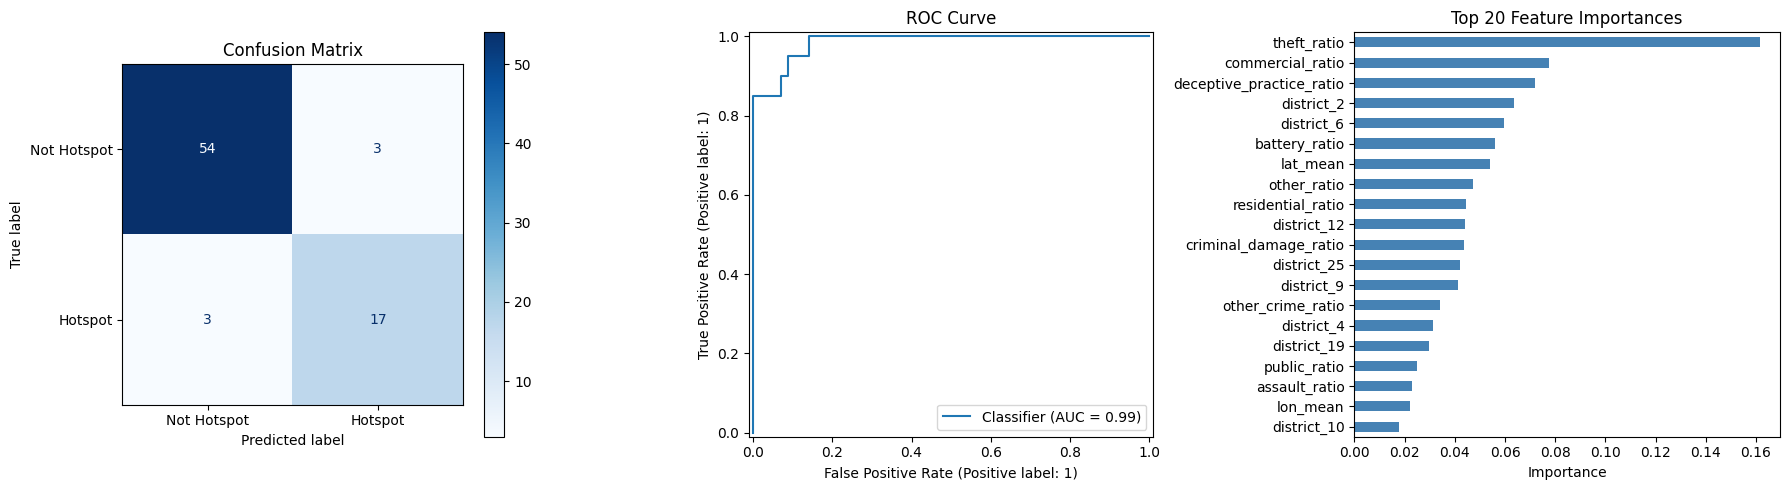

Saved to docs/xgboost_results.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Confusion Matrix ---
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Hotspot', 'Hotspot'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

# --- ROC Curve ---
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1])
axes[1].set_title('ROC Curve')

# --- Feature Importance ---
importances = pd.Series(
    tuned_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(20)

importances.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Top 20 Feature Importances')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../src/figures/xgboost_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to src/figures/xgboost_results.png')

## 7. Ablation Study — Feature Importance Validation

Remove top features one by one to quantify their individual contribution to model performance.

In [9]:
# Get top features from tuned model
feature_importance = pd.Series(
    tuned_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = feature_importance.head(5).index.tolist()
print("Top 5 features to ablate:", top_features)

# Ablation: remove each top feature one at a time
ablation_results = []

# Full model baseline (test set)
full_auc   = roc_auc_score(y_test, y_pred_prob)
full_f1    = f1_score(y_test, y_pred)
full_prec  = precision_score(y_test, y_pred)
full_recall= recall_score(y_test, y_pred)

ablation_results.append({
    'Removed Feature': 'None (full model)',
    'AUC-ROC': full_auc,
    'F1': full_f1,
    'Precision': full_prec,
    'Recall': full_recall
})

for feat in top_features:
    X_train_abl = X_train.drop(columns=[feat])
    X_test_abl  = X_test.drop(columns=[feat])

    abl_model = XGBClassifier(
        **study.best_params,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='auc',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    abl_model.fit(X_train_abl, y_train)

    y_pred_abl      = abl_model.predict(X_test_abl)
    y_pred_prob_abl = abl_model.predict_proba(X_test_abl)[:, 1]

    ablation_results.append({
        'Removed Feature': feat,
        'AUC-ROC': roc_auc_score(y_test, y_pred_prob_abl),
        'F1': f1_score(y_test, y_pred_abl),
        'Precision': precision_score(y_test, y_pred_abl),
        'Recall': recall_score(y_test, y_pred_abl)
    })

ablation_df = pd.DataFrame(ablation_results).set_index('Removed Feature').round(4)
print(ablation_df.to_string())

Top 5 features to ablate: ['theft_ratio', 'commercial_ratio', 'deceptive_practice_ratio', 'district_2', 'district_6']
                          AUC-ROC      F1  Precision  Recall
Removed Feature                                             
None (full model)          0.9851  0.8500     0.8500    0.85
theft_ratio                0.9868  0.8500     0.8500    0.85
commercial_ratio           0.9825  0.8780     0.8571    0.90
deceptive_practice_ratio   0.9807  0.8718     0.8947    0.85
district_2                 0.9781  0.8947     0.9444    0.85
district_6                 0.9860  0.9000     0.9000    0.90


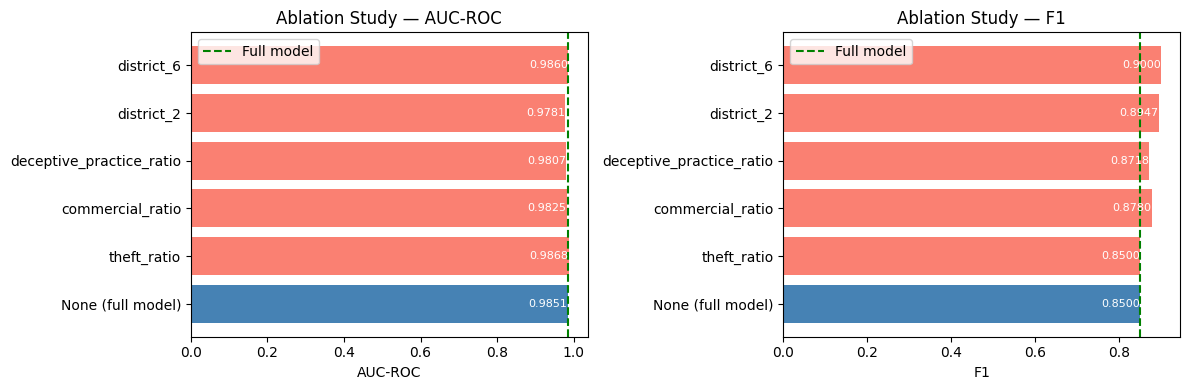

Saved to docs/xgboost_ablation.png


In [ ]:
# Visualize ablation results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metrics = ['AUC-ROC', 'F1']
colors  = ['steelblue' if i == 0 else 'salmon' for i in range(len(ablation_df))]

for ax, metric in zip(axes, metrics):
    bars = ax.barh(ablation_df.index, ablation_df[metric], color=colors)
    ax.axvline(ablation_df.loc['None (full model)', metric], color='green',
               linestyle='--', linewidth=1.5, label='Full model')
    ax.set_title(f'Ablation Study — {metric}')
    ax.set_xlabel(metric)
    ax.legend()
    # Annotate values
    for bar, val in zip(bars, ablation_df[metric]):
        ax.text(val - 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha='right', fontsize=8, color='white')

plt.tight_layout()
plt.savefig('../src/figures/xgboost_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to src/figures/xgboost_ablation.png')

## 7. Baseline vs Tuned Comparison

           Baseline (CV mean)  Tuned (CV mean)
Metric                                        
precision              0.8806           0.8552
recall                 0.8786           0.9071
f1                     0.8782           0.8774
roc_auc                0.9718           0.9750


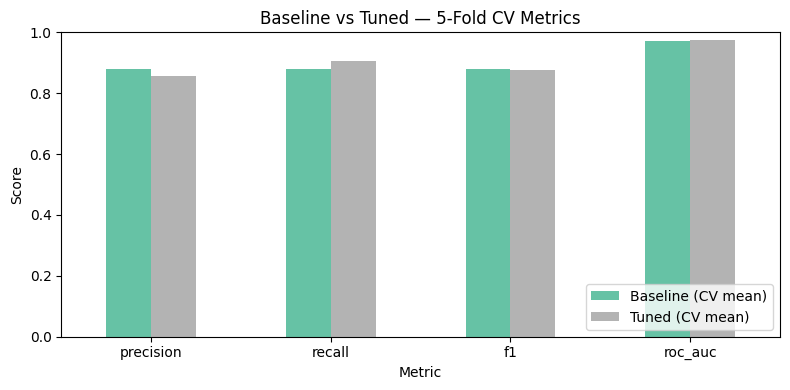

In [11]:
comparison = pd.DataFrame({
    'Metric': scoring,
    'Baseline (CV mean)': [cv_results[f'test_{m}'].mean() for m in scoring],
    'Tuned (CV mean)':    [tuned_cv_results[f'test_{m}'].mean() for m in scoring],
})
comparison = comparison.set_index('Metric').round(4)
print(comparison.to_string())

comparison.plot(kind='bar', figsize=(8, 4), rot=0, colormap='Set2')
plt.title('Baseline vs Tuned — 5-Fold CV Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Spatial Accuracy Evaluation

Since explicit district labels are unavailable, we partition the test set into four geographic quadrants using the median of `lat_mean` and `lon_mean`, then evaluate model performance per quadrant.

In [12]:
# Build a working copy of test set with predictions
spatial_df = X_test.copy()
spatial_df['y_true']      = y_test.values
spatial_df['y_pred']      = y_pred
spatial_df['y_pred_prob'] = y_pred_prob

# Assign quadrant labels based on median lat/lon
lat_mid = spatial_df['lat_mean'].median()
lon_mid = spatial_df['lon_mean'].median()

def assign_quadrant(row):
    ns = 'North' if row['lat_mean'] >= lat_mid else 'South'
    ew = 'East'  if row['lon_mean'] >= lon_mid else 'West'
    return f'{ns}-{ew}'

spatial_df['quadrant'] = spatial_df.apply(assign_quadrant, axis=1)
print('Samples per quadrant:\n', spatial_df['quadrant'].value_counts())

# Evaluate per quadrant
spatial_results = []
for quad, grp in spatial_df.groupby('quadrant'):
    if grp['y_true'].nunique() < 2:   # skip if only one class
        continue
    spatial_results.append({
        'Quadrant':  quad,
        'N':         len(grp),
        'Hotspot%':  f"{grp['y_true'].mean()*100:.1f}%",
        'Precision': precision_score(grp['y_true'], grp['y_pred'], zero_division=0),
        'Recall':    recall_score(grp['y_true'], grp['y_pred'], zero_division=0),
        'F1':        f1_score(grp['y_true'], grp['y_pred'], zero_division=0),
        'AUC-ROC':   roc_auc_score(grp['y_true'], grp['y_pred_prob']),
    })

spatial_results_df = pd.DataFrame(spatial_results).set_index('Quadrant').round(4)
print('\n=== Spatial Accuracy by Quadrant ===')
print(spatial_results_df.to_string())

Samples per quadrant:
 quadrant
North-West    27
South-East    27
North-East    12
South-West    11
Name: count, dtype: int64

=== Spatial Accuracy by Quadrant ===
             N Hotspot%  Precision  Recall      F1  AUC-ROC
Quadrant                                                   
North-East  12    50.0%     1.0000  0.6667  0.8000   1.0000
North-West  27    22.2%     0.7143  0.8333  0.7692   0.9762
South-East  27    25.9%     0.8750  1.0000  0.9333   1.0000
South-West  11     9.1%     1.0000  1.0000  1.0000   1.0000


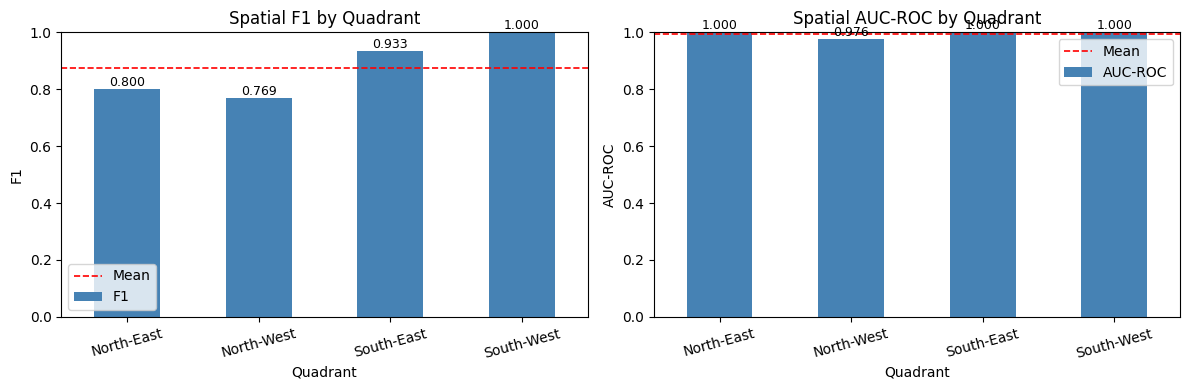

Saved to docs/xgboost_spatial.png


In [ ]:
# Visualize spatial performance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ['F1', 'AUC-ROC']):
    spatial_results_df[metric].plot(kind='bar', ax=ax, color='steelblue', rot=15)
    ax.set_title(f'Spatial {metric} by Quadrant')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.axhline(spatial_results_df[metric].mean(), color='red',
               linestyle='--', linewidth=1.2, label='Mean')
    ax.legend()
    for i, v in enumerate(spatial_results_df[metric]):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../src/figures/xgboost_spatial.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to src/figures/xgboost_spatial.png')

## 8. Save Best Model

In [ ]:
import joblib, os

os.makedirs('../models', exist_ok=True)
joblib.dump(tuned_model, '..src/models/xgboost_hotspot.pkl')
print('Model saved to src/models/xgboost_hotspot.pkl')

Model saved to models/xgboost_hotspot.pkl
